In [2]:
import pandas as pd

df = pd.read_csv("../data/ecommerce_logistics_carbon_emissions_v1.csv")

df.head()

,Transaction_ID,Date,Origin_Facility,Destination_City,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Is_Eco_Friendly
0,TRX-F775953B,2025-02-18,Jakarta Fulfillment Center,Waynehaven,Electric Van (EV),Mixed Route,80.4,15.6,Normal,4.100,1
1,TRX-B4C50003,2025-09-11,Jakarta Fulfillment Center,East Patriciaside,Diesel Van (Euro 6),Mixed Route,135.3,18.8,Low,23.130,0
2,TRX-F7C71F39,2025-06-15,Semarang Depot,Pottershire,Drone Delivery,Urban Last Mile,9.0,25.4,Normal,0.091,1
3,TRX-A60E6AAA,2025-06-23,Semarang Depot,North Christina,Drone Delivery,Urban Last Mile,11.8,13.5,High,0.101,1
4,TRX-D0CFAF87,2025-02-15,Jakarta Fulfillment Center,Lisamouth,Heavy Truck,Inter-City,156.5,1792.6,Normal,128.004,0


In [14]:
print("=== HEAD ===")
print(df.head())

print("\n=== COLUMNS ===")
print(df.columns)


=== HEAD ===
  Transaction_ID        Date             Origin_Facility   Destination_City  \
0   TRX-F775953B  2025-02-18  Jakarta Fulfillment Center         Waynehaven   
1   TRX-B4C50003  2025-09-11  Jakarta Fulfillment Center  East Patriciaside   
2   TRX-F7C71F39  2025-06-15              Semarang Depot        Pottershire   
3   TRX-A60E6AAA  2025-06-23              Semarang Depot    North Christina   
4   TRX-D0CFAF87  2025-02-15  Jakarta Fulfillment Center          Lisamouth   

          Vehicle_Type       Route_Type  Distance_KM  Package_Weight_KG  \
0    Electric Van (EV)      Mixed Route         80.4               15.6   
1  Diesel Van (Euro 6)      Mixed Route        135.3               18.8   
2       Drone Delivery  Urban Last Mile          9.0               25.4   
3       Drone Delivery  Urban Last Mile         11.8               13.5   
4          Heavy Truck       Inter-City        156.5             1792.6   

  Traffic_Conditions  Carbon_Emission_kgCO2e  Is_Eco_Friendly

In [10]:
print("=== INFO ===")
print(df.info())

=== INFO ===
<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Transaction_ID          12000 non-null  str    
 1   Date                    12000 non-null  str    
 2   Origin_Facility         12000 non-null  str    
 3   Destination_City        12000 non-null  str    
 4   Vehicle_Type            12000 non-null  str    
 5   Route_Type              12000 non-null  str    
 6   Distance_KM             12000 non-null  float64
 7   Package_Weight_KG       12000 non-null  float64
 8   Traffic_Conditions      12000 non-null  str    
 9   Carbon_Emission_kgCO2e  12000 non-null  float64
 10  Is_Eco_Friendly         12000 non-null  int64  
dtypes: float64(3), int64(1), str(7)
memory usage: 1.0 MB
None


In [12]:
print("=== DESCRIBE ===")
print(df.describe())


=== DESCRIBE ===
        Distance_KM  Package_Weight_KG  Carbon_Emission_kgCO2e  \
count  12000.000000       12000.000000            12000.000000   
mean     102.851408         396.355458               71.994260   
std      163.538763        1064.274964              180.524361   
min        1.000000           0.500000                0.000000   
25%       11.600000           8.800000                0.093000   
50%       37.500000          17.300000                4.150000   
75%      114.600000          26.100000               24.091250   
max      799.900000        4985.500000             1280.173000   

       Is_Eco_Friendly  
count     12000.000000  
mean          0.427000  
std           0.494663  
min           0.000000  
25%           0.000000  
50%           0.000000  
75%           1.000000  
max           1.000000  


In [16]:
print("=== NULL VALUES ===")
print(df.isnull().sum())

=== NULL VALUES ===
Transaction_ID            0
Date                      0
Origin_Facility           0
Destination_City          0
Vehicle_Type              0
Route_Type                0
Distance_KM               0
Package_Weight_KG         0
Traffic_Conditions        0
Carbon_Emission_kgCO2e    0
Is_Eco_Friendly           0
dtype: int64


In [17]:
print("=== DUPLICATE VALUES ===")
print(df.duplicated().sum())

=== DUPLICATE VALUES ===
0


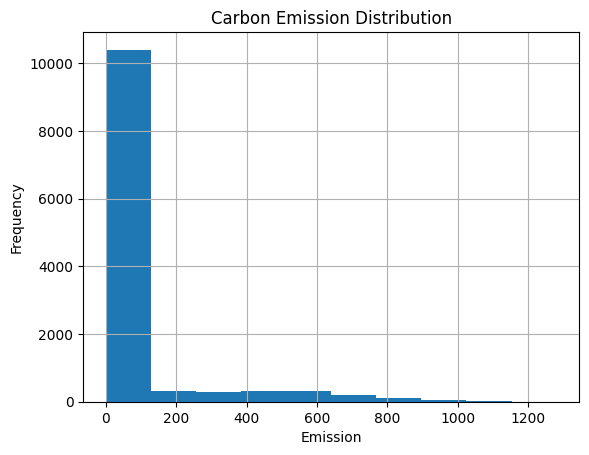

In [26]:
import matplotlib.pyplot as plt

df["Carbon_Emission_kgCO2e"].hist()

plt.title("Carbon Emission Distribution")
plt.xlabel("Emission")
plt.ylabel("Frequency")

plt.savefig("../charts/emission_distribution.png")

plt.show()

In [31]:
total_shipments = len(df)

total_emissions = df["Carbon_Emission_kgCO2e"].sum()

average_emissions = df["Carbon_Emission_kgCO2e"].mean()

average_distance = df["Distance_KM"].mean()

print(f"Total Shipments: {total_shipments}")
print(f"Total CO2 Emissions: {total_emissions:.2f} kgCO2e")
print(f"Average Emission per Shipment: {average_emissions:.2f}")
print(f"Average Distance: {average_distance:.2f} km")

Total Shipments: 12000
Total CO2 Emissions: 863931.12 kgCO2e
Average Emission per Shipment: 71.99
Average Distance: 102.85 km


In [32]:
vehicle_emissions = (
    df.groupby("Vehicle_Type")["Carbon_Emission_kgCO2e"]
    .mean()
    .sort_values(ascending=False)
)

print(vehicle_emissions)

Vehicle_Type
Heavy Truck             463.138771
Diesel Van (Euro 4)      25.913168
Diesel Van (Euro 6)      17.115735
Electric Van (EV)         4.059115
Motorcycle (Courier)      2.505052
Drone Delivery            0.064592
Cargo Bicycle             0.000000
Name: Carbon_Emission_kgCO2e, dtype: float64


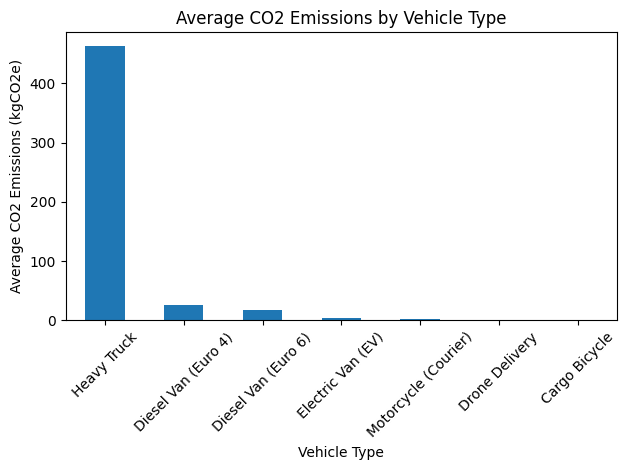

In [37]:
vehicle_emissions.plot(kind="bar")

plt.title("Average CO2 Emissions by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Average CO2 Emissions (kgCO2e)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("../charts/vehicle_type_emissions.png")


plt.show()

In [35]:
route_emissions = (
    df.groupby("Route_Type")["Carbon_Emission_kgCO2e"]
    .mean()
    .sort_values(ascending=False)
)

print(route_emissions)

Route_Type
Inter-City         463.138771
Mixed Route         15.677152
Inter-District       2.505052
Urban Last Mile      0.031856
Name: Carbon_Emission_kgCO2e, dtype: float64


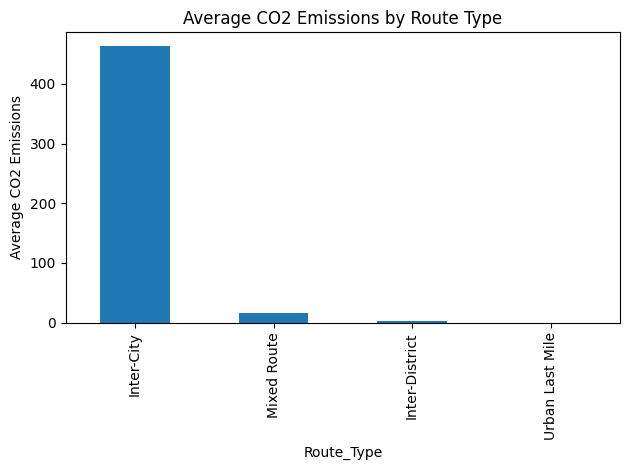

In [38]:
route_emissions.plot(kind="bar")

plt.title("Average CO2 Emissions by Route Type")
plt.ylabel("Average CO2 Emissions")

plt.tight_layout()

plt.savefig("../charts/route_type_emissions.png")

plt.show()

In [39]:
traffic_analysis = (
    df.groupby("Traffic_Conditions")["Carbon_Emission_kgCO2e"]
    .mean()
)

print(traffic_analysis)

Traffic_Conditions
High                 88.049668
Low                  53.781689
Normal               61.727729
Severe Congestion    99.532728
Name: Carbon_Emission_kgCO2e, dtype: float64


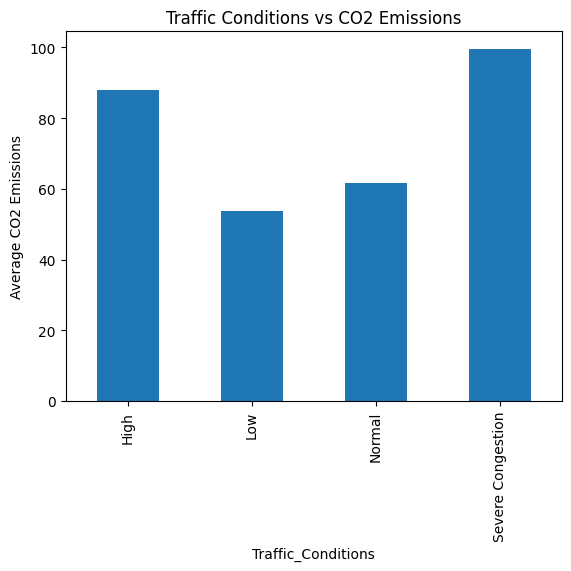

In [41]:
traffic_analysis.plot(kind="bar")

plt.title("Traffic Conditions vs CO2 Emissions")

plt.ylabel("Average CO2 Emissions")

plt.savefig("../charts/traffic_conditions_emissions.png")

plt.show()

In [42]:
eco_ratio = (
    df["Is_Eco_Friendly"].mean() * 100
)

print(f"Eco-Friendly Deliveries: {eco_ratio:.2f}%")

Eco-Friendly Deliveries: 42.70%


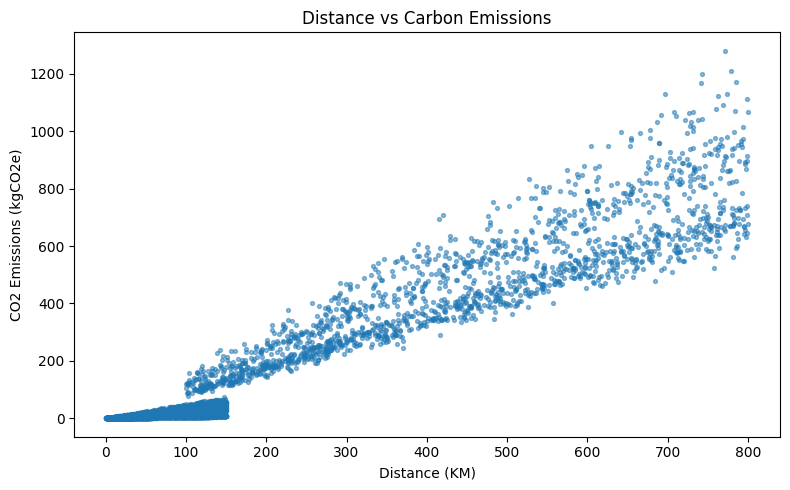

In [57]:
plt.figure(figsize=(8,5))

plt.scatter(
    df["Distance_KM"],
    df["Carbon_Emission_kgCO2e"],
    s=8,
    alpha=0.5
)

plt.xlabel("Distance (KM)")
plt.ylabel("CO2 Emissions (kgCO2e)")
plt.title("Distance vs Carbon Emissions")

plt.tight_layout()

plt.savefig("../charts/distance_vs_emissions.png")

plt.show()

In [58]:
df["Emission_per_KM"] = (
    df["Carbon_Emission_kgCO2e"] / df["Distance_KM"]
)

In [59]:
top_inefficient = df.sort_values(
    by="Emission_per_KM",
    ascending=False
)

top_inefficient.head(10)

,Transaction_ID,Date,Origin_Facility,Destination_City,Vehicle_Type,Route_Type,Distance_KM,Package_Weight_KG,Traffic_Conditions,Carbon_Emission_kgCO2e,Is_Eco_Friendly,Emission_per_KM
6763,TRX-FA64F6CA,2025-10-24,Bandung Hub,Alexandraville,Heavy Truck,Inter-City,420.1,4329.6,Severe Congestion,707.894,0,1.685061
10637,TRX-1844D2EC,2025-04-23,Semarang Depot,South Laurie,Heavy Truck,Inter-City,142.4,4663.7,Severe Congestion,239.420,0,1.681320
4791,TRX-A8E4D9E7,2025-10-06,Bandung Hub,Normanview,Heavy Truck,Inter-City,415.2,3139.3,Severe Congestion,694.571,0,1.672859
1602,TRX-AB747A90,2025-04-28,Jakarta Fulfillment Center,East Jay,Heavy Truck,Inter-City,770.9,4903.4,Severe Congestion,1280.173,0,1.660621
1997,TRX-B7052562,2025-11-28,Medan Distribution,Masonchester,Heavy Truck,Inter-City,227.7,4717.3,Severe Congestion,376.413,0,1.653109
5985,TRX-1104E48E,2025-02-22,Bandung Hub,Brandonbury,Heavy Truck,Inter-City,138.8,4853.7,Severe Congestion,228.132,0,1.643602
6978,TRX-61C6CF1B,2025-04-21,Medan Distribution,North Leetown,Heavy Truck,Inter-City,696.8,3647.0,Severe Congestion,1130.921,0,1.623021
7875,TRX-34129FE7,2025-09-12,Medan Distribution,Cynthiaborough,Heavy Truck,Inter-City,742.7,3389.4,Severe Congestion,1200.512,0,1.616416
6157,TRX-6F3C4EFB,2025-06-03,Surabaya Warehouse,Ryanshire,Heavy Truck,Inter-City,292.4,4401.1,Severe Congestion,471.977,0,1.614148
249,TRX-A6575825,2025-01-04,Jakarta Fulfillment Center,Dylanview,Heavy Truck,Inter-City,346.4,2915.4,Severe Congestion,555.305,0,1.603074


In [60]:
facility_analysis = (
    df.groupby("Origin_Facility")["Carbon_Emission_kgCO2e"]
    .mean()
    .sort_values(ascending=False)
)

print(facility_analysis)

Origin_Facility
Semarang Depot                83.590867
Medan Distribution            73.600740
Bandung Hub                   69.290886
Makassar Port                 68.647684
Jakarta Fulfillment Center    68.629097
Surabaya Warehouse            68.228782
Name: Carbon_Emission_kgCO2e, dtype: float64


In [61]:
df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.month

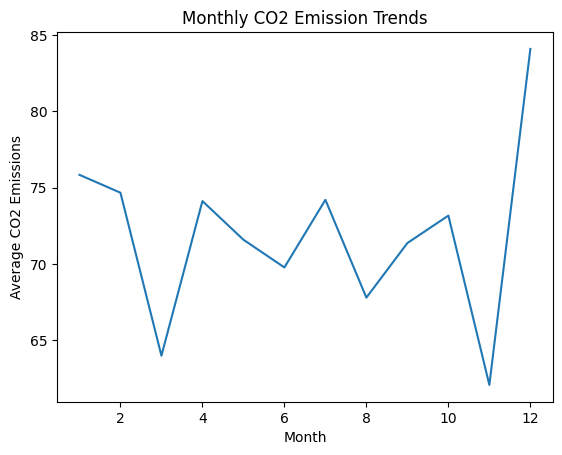

In [63]:
monthly_emissions = (
    df.groupby("Month")["Carbon_Emission_kgCO2e"]
    .mean()
)

monthly_emissions.plot()

plt.title("Monthly CO2 Emission Trends")

plt.ylabel("Average CO2 Emissions")

plt.savefig("../charts/monthly_emission_trends.png")

plt.show()

---KEY FINDINGS

- Heavy Trucks generate the highest average CO2 emissions.
- High traffic conditions significantly increase delivery emissions.
- Inter-City routes are the least eco-efficient operations.
- Electric vehicles and drone deliveries show the best sustainability performance.
- Certain fulfillment centers exhibit above-average emission levels.